In [1]:
#Montar drive para extraer archivos

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
#Cargar el archivo CSV desde la ruta especificada
df = pd.read_csv("/content/drive/MyDrive/ProyectoIA/esc50.csv")
print(df.head())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


In [3]:
#Mapeo de las rutas de los espectrogramas
import os
spect_path = "/content/drive/MyDrive/ProyectoIA/espectogramas"
df["spect_path"] = df["filename"].apply(lambda x: os.path.join(spect_path, x.replace(".wav", ".png")))
pd.set_option('display.max_colwidth', None)
print(df.head())

            filename  fold  target        category  esc10  src_file take  \
0   1-100032-A-0.wav     1       0             dog   True    100032    A   
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A   
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A   
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B   
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A   

                                                          spect_path  
0   /content/drive/MyDrive/ProyectoIA/espectogramas/1-100032-A-0.png  
1  /content/drive/MyDrive/ProyectoIA/espectogramas/1-100038-A-14.png  
2  /content/drive/MyDrive/ProyectoIA/espectogramas/1-100210-A-36.png  
3  /content/drive/MyDrive/ProyectoIA/espectogramas/1-100210-B-36.png  
4  /content/drive/MyDrive/ProyectoIA/espectogramas/1-101296-A-19.png  


In [4]:
#Media y desviacion obtenidos de forma local para la normalizacion
#Se utiliza para normalizar los espectrogramas antes de ingresarlos al modelo
MEAN = [0.4241387,  0.1550668,  0.31883597]
STD = [0.35462896, 0.16410387,  0.19566532]

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

# Estadísticas calculadas previamente
# Definición del Dataset personalizado para ESC-50 y normalización explícita

class ESC50Dataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Cargar imagen desde la ruta
        img_path = self.df.iloc[idx]["spect_path"]
        img = Image.open(img_path).convert("RGB")

        # Convertir a tensor en rango [0,1]
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)

        # Normalización explícita canal por canal
        for c in range(3):
            img_tensor[c] = (img_tensor[c] - MEAN[c]) / STD[c]

        # Etiqueta numérica
        label = self.df.iloc[idx]["target"]

        return img_tensor, label

In [6]:
def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(42)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#Mantener constante el kernel size de 3 y el padding de 1
# Configuración de convolución 3x3
conv_k_3 = lambda in_channels, out_channels, stride: nn.Conv2d(
    in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
)

#Clase para los bloques residuales
# Bloque residual básico (para ResNet-18)
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv_k_3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = conv_k_3(out_channels, out_channels, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    #funcion para realizar la suma de la salida de un bloque a la salida del bloque siguiente
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


In [8]:
import torch.optim as optim
# ResNet-18 adaptado para ESC-50
class ResNet18(nn.Module):
    def __init__(self, num_classes=50, dropout=0.5):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        # Conv inicial y max pooling (estándar para 224x224)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # Etapas: 2 bloques por etapa (64, 128, 256, 512 canales)
        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)
        # Average pooling y FC
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout) #Desactivar parte de las neuronas para evitar memorizar del entrenamiento
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))  # [batch_size, 64, 112, 112]
        x = self.maxpool(x)                     # [batch_size, 64, 56, 56]
        x = self.layer1(x)                      # [batch_size, 64, 56, 56]
        x = self.layer2(x)                      # [batch_size, 128, 28, 28]
        x = self.layer3(x)                      # [batch_size, 256, 14, 14]
        x = self.layer4(x)                      # [batch_size, 512, 7, 7]
        x = self.avgpool(x)                     # [batch_size, 512, 1, 1]
        x = x.view(x.size(0), -1)               # [batch_size, 512]
        x = self.dropout(x)
        x = self.fc(x)                          # [batch_size, 50]
        return x

In [9]:
import wandb
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score

# Funcion de entrenamiento
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, run_name):
    best_val_acc = 0.0
    patience, no_improve = 5, 0
    for epoch in range(num_epochs):
        model.train()
        train_loss = train_correct = train_total = 0.0
        train_y_true, train_y_pred = [], []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_y_true.extend(labels.cpu().numpy())
            train_y_pred.extend(predicted.cpu().numpy())
        train_loss /= train_total
        train_acc = train_correct / train_total
        train_f1 = f1_score(train_y_true, train_y_pred, average='macro')

        # Validación
        model.eval()
        val_loss = val_correct = val_total = 0.0
        val_y_true, val_y_pred = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_y_true.extend(labels.cpu().numpy())
                val_y_pred.extend(predicted.cpu().numpy())
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(val_y_true, val_y_pred, average='macro')
        val_precision = precision_score(val_y_true, val_y_pred, average='macro', zero_division=0)
        val_recall = recall_score(val_y_true, val_y_pred, average='macro', zero_division=0)
        scheduler.step(val_acc)

        # Logging
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
            "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
            "val_precision": val_precision, "val_recall": val_recall,
            "lr": optimizer.param_groups[0]['lr']
        })

        print(f"[{epoch+1}/{num_epochs}] Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        # Guardar mejor modelo
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0
            torch.save(model.state_dict(),
                       f"/content/drive/MyDrive/ProyectoIA/entrenamiento/best_model_{run_name}.pth")
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break
    return best_val_acc


In [10]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

# TEST FIJO: fold 5
df_test = df[df["fold"] == 5].reset_index(drop=True)
test_dataset = ESC50Dataset(df_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# TRAIN/VAL: folds 1,2,3,4
df_train_val = df[df["fold"].isin([1, 2, 3, 4])].reset_index(drop=True)

print(f"Train/Val: {len(df_train_val)} muestras | Test: {len(df_test)} muestras")

# DIRECTORIO PARA MODELOS
save_dir = "/content/drive/MyDrive/ProyectoIA/entrenamiento/modelo"
os.makedirs(save_dir, exist_ok=True)

# SWEEP CONFIG  (Hiperparametros)
sweep_config = {
    "method": "grid",
    "metric": {"name": "mean_val_acc", "goal": "maximize"},
    "parameters": {
        "learning_rate": {"values": [0.008, 0.007, 0.001]},
        "optimizer": {"value": "SGD"},
        "weight_decay": {"values": [1e-4, 5e-4, 1e-3]},
        "dropout": {"values": [0.3, 0.5]},
        "epochs": {"value": 30}
    }
}
#Generar un nuevo proyecto en wandb
sweep_id = wandb.sweep(sweep_config, project="esc50-resnet18-5fold-cv")

# Run_sweep CON 5-FOLD CV
def run_sweep():
    wandb.init(project="esc50-resnet18-5fold-cv")
    #Fijar reproducibilidad
    set_seeds(42)

    lr = wandb.config.learning_rate
    wd = wandb.config.weight_decay
    dropout = wandb.config.dropout

    run_name = f"SGD-lr{lr}-wd{wd}-do{dropout}"
    wandb.run.name = run_name
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_val_accs = []
    best_fold_model_path = None
    best_fold_val_acc = 0.0

    use_cuda = torch.cuda.is_available()  # ← para pin_memory

    for fold, (train_idx, val_idx) in enumerate(skf.split(df_train_val, df_train_val['target'])):
        print(f"\n--- FOLD {fold+1}/5 (Train/Val) ---")

        train_df = df_train_val.iloc[train_idx].reset_index(drop=True)
        val_df = df_train_val.iloc[val_idx].reset_index(drop=True)

        train_dataset = ESC50Dataset(train_df)
        val_dataset = ESC50Dataset(val_df)
        # DataLoaders (pin_memory y num_workers)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                                  num_workers=2, pin_memory=use_cuda)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                                num_workers=2, pin_memory=use_cuda)

        #Instancia del modelo con la arquitectura resnet18 disenada
        model = ResNet18(num_classes=50, dropout=dropout).to(device)
        criterion = nn.CrossEntropyLoss()

        #Optimizador SGD
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=wd
        )

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

        fold_run_name = f"{run_name}_cvfold{fold+1}"
        val_acc = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            num_epochs=30,
            device=device,
            run_name=fold_run_name
        )

        fold_val_accs.append(val_acc)

        if val_acc > best_fold_val_acc:
            best_fold_val_acc = val_acc
            best_fold_model_path = f"{save_dir}/temp_best_{run_name}.pth"
            torch.save(model.state_dict(), best_fold_model_path)

        wandb.log({f"cv_fold_{fold+1}_val_acc": val_acc})

    mean_val_acc = np.mean(fold_val_accs)
    std_val_acc = np.std(fold_val_accs)

    wandb.log({
        "mean_val_acc": mean_val_acc,
        "std_val_acc": std_val_acc,
        "best_val_acc_in_cv": best_fold_val_acc
    })

    final_model_path = f"{save_dir}/best_model_{run_name}.pth"
    os.replace(best_fold_model_path, final_model_path)
    wandb.log({"best_model_path": final_model_path})

    print(f"\nRUN COMPLETADO: {run_name}")
    print(f"Mean Val Acc: {mean_val_acc:.4f} ± {std_val_acc:.4f}")
    print(f"Mejor modelo guardado: {final_model_path}")

    wandb.finish()

# === EJECUTAR ===
wandb.login()
wandb.agent(sweep_id, run_sweep, count=6)


Train/Val: 1600 muestras | Test: 400 muestras


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


...


--- FOLD 1/5 (Train/Val) ---
[1/30] Train Acc: 0.0664, Val Acc: 0.1031, F1: 0.0472
[2/30] Train Acc: 0.2141, Val Acc: 0.1812, F1: 0.1482
[3/30] Train Acc: 0.3180, Val Acc: 0.3438, F1: 0.2849
[4/30] Train Acc: 0.4359, Val Acc: 0.3688, F1: 0.3398
[5/30] Train Acc: 0.5352, Val Acc: 0.4688, F1: 0.4323
[6/30] Train Acc: 0.6117, Val Acc: 0.5375, F1: 0.4999
[7/30] Train Acc: 0.6703, Val Acc: 0.4688, F1: 0.4399
[8/30] Train Acc: 0.7172, Val Acc: 0.4688, F1: 0.4481
[9/30] Train Acc: 0.8031, Val Acc: 0.3844, F1: 0.3842
[10/30] Train Acc: 0.8680, Val Acc: 0.5281, F1: 0.5175
[11/30] Train Acc: 0.9336, Val Acc: 0.6375, F1: 0.6284
[12/30] Train Acc: 0.9461, Val Acc: 0.6125, F1: 0.5979
[13/30] Train Acc: 0.9625, Val Acc: 0.6000, F1: 0.5829
[14/30] Train Acc: 0.9695, Val Acc: 0.5813, F1: 0.5721
[15/30] Train Acc: 0.9898, Val Acc: 0.6687, F1: 0.6525
[16/30] Train Acc: 0.9945, Val Acc: 0.6937, F1: 0.6856
[17/30] Train Acc: 1.0000, Val Acc: 0.6813, F1: 0.6705
[18/30] Train Acc: 0.9961, Val Acc: 0.6687, 

best_val_acc_in_cv,▁
cv_fold_1_val_acc,▁
cv_fold_2_val_acc,▁
cv_fold_3_val_acc,▁
cv_fold_4_val_acc,▁
cv_fold_5_val_acc,▁
epoch,▃▃▃▄▅▁▃▄▄▅▆▆▆▇▇▂▃▃▃▄▅█▂▂▂▄▄▅▆▆▇▁▃▃▄▅▅▆▆▇
lr,███▄▄▂▂█████▄▂▂▁███▄▄▄▄▄▂██▄▄▄▂████▄▄▄▄▁
mean_val_acc,▁
std_val_acc,▁
+8,...


wandb: Agent Starting Run: ajcz4we5 with config:
wandb: 	dropout: 0.3
wandb: 	epochs: 30
wandb: 	learning_rate: 0.007
wandb: 	optimizer: SGD
wandb: 	weight_decay: 0.001



--- FOLD 1/5 (Train/Val) ---
[1/30] Train Acc: 0.0664, Val Acc: 0.1250, F1: 0.0566
[2/30] Train Acc: 0.2070, Val Acc: 0.1812, F1: 0.1289
[3/30] Train Acc: 0.2969, Val Acc: 0.2156, F1: 0.1516
[4/30] Train Acc: 0.4375, Val Acc: 0.3406, F1: 0.3085
[5/30] Train Acc: 0.5203, Val Acc: 0.4688, F1: 0.4292
[6/30] Train Acc: 0.5969, Val Acc: 0.4562, F1: 0.4252
[7/30] Train Acc: 0.6719, Val Acc: 0.4688, F1: 0.4239
[8/30] Train Acc: 0.7055, Val Acc: 0.4188, F1: 0.3895
[9/30] Train Acc: 0.8313, Val Acc: 0.5781, F1: 0.5535
[10/30] Train Acc: 0.8711, Val Acc: 0.5344, F1: 0.5178
[11/30] Train Acc: 0.9211, Val Acc: 0.6406, F1: 0.6340
[12/30] Train Acc: 0.9375, Val Acc: 0.6031, F1: 0.5923
[13/30] Train Acc: 0.9461, Val Acc: 0.6094, F1: 0.5939
[14/30] Train Acc: 0.9648, Val Acc: 0.6625, F1: 0.6556
[15/30] Train Acc: 0.9797, Val Acc: 0.6781, F1: 0.6673
[16/30] Train Acc: 0.9820, Val Acc: 0.6594, F1: 0.6492
[17/30] Train Acc: 0.9945, Val Acc: 0.6625, F1: 0.6480
[18/30] Train Acc: 0.9938, Val Acc: 0.6687, 

best_val_acc_in_cv,▁
cv_fold_1_val_acc,▁
cv_fold_2_val_acc,▁
cv_fold_3_val_acc,▁
cv_fold_4_val_acc,▁
cv_fold_5_val_acc,▁
epoch,▁▂▂▃▄▅▆▆▇▂▃▃▄▅▆▇█▂▂▂▅▅▆▂▂▃▄▄▅▆▇▇██▁▃▃▅▅▆
lr,███▄▄▁▁▁████▄▄▄▄▂▂████▄▄▂████▄▁▁█████▄▂▂
mean_val_acc,▁
std_val_acc,▁
+8,...



TEST RESULTS
Accuracy:     0.6425
F1-score:     0.6231
Precision:    0.6360
Recall:       0.6425
Loss:         1.4024
AUC (macro):  0.9760
AUC (weighted): 0.9760


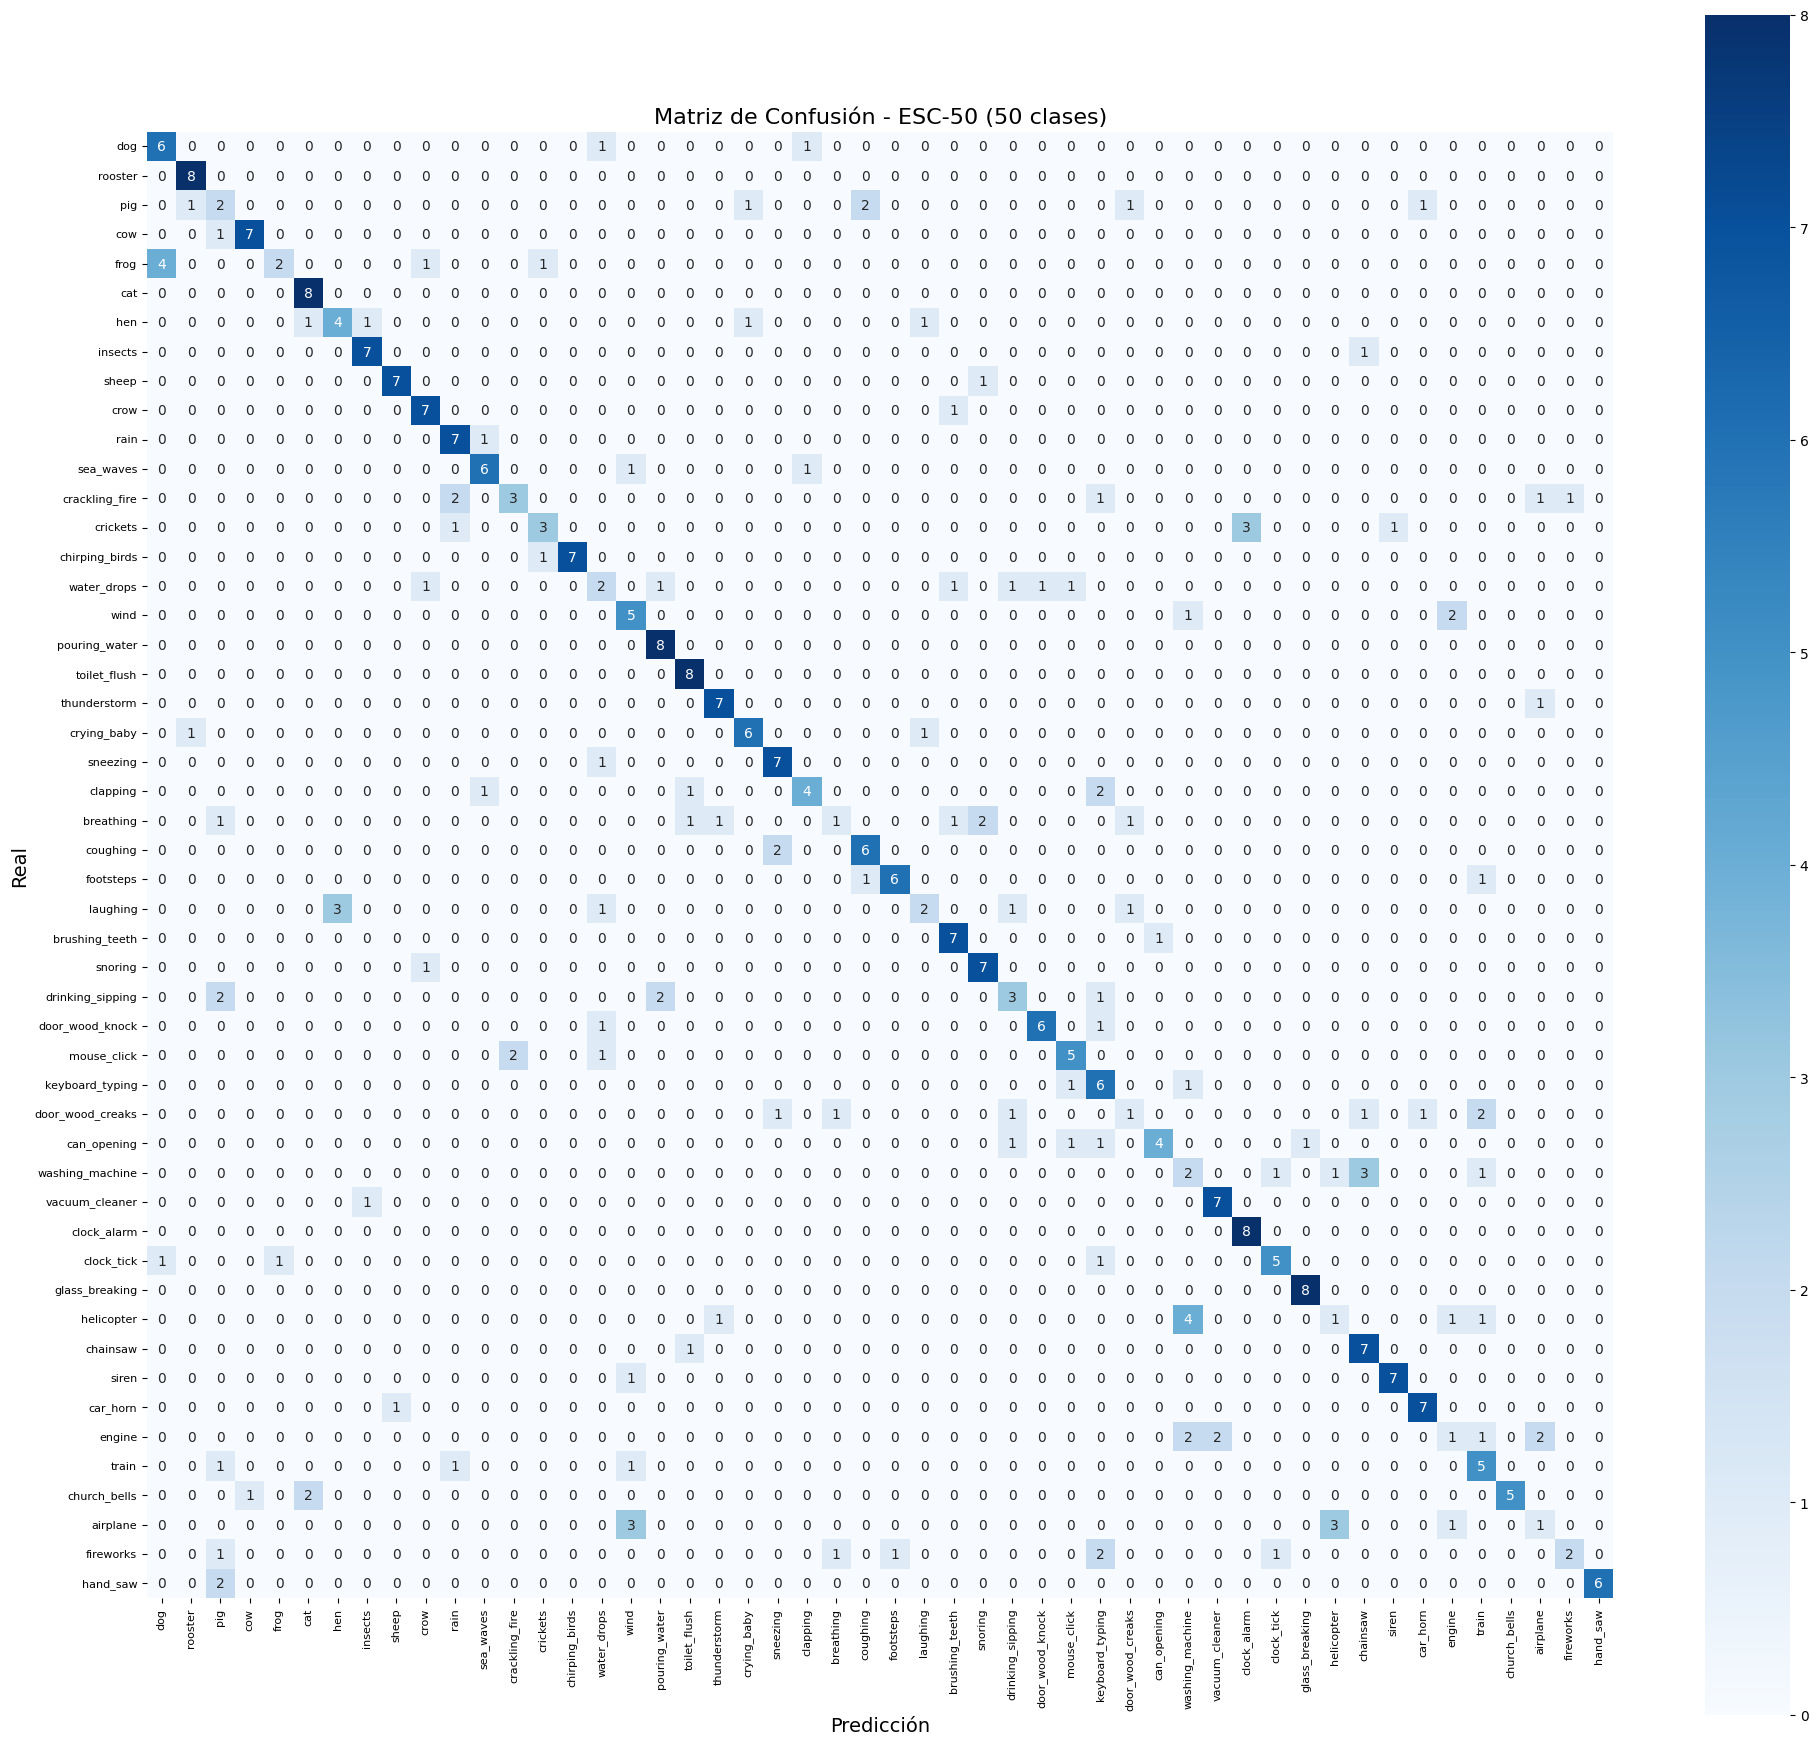


Matriz guardada en: /content/drive/MyDrive/ProyectoIA/test/confusion_matrix.png
Tabla por clase (con AUC) guardada en: /content/drive/MyDrive/ProyectoIA/test/metrics_per_class.csv

EVALUACIÓN COMPLETA TERMINADA
AUC Macro: 0.9760 | AUC Weighted: 0.9760


In [11]:
# FINAL TEST ###

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             roc_auc_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import pandas as pd

# === FUNCIÓN DE EVALUACIÓN COMPLETA ===
def evaluate_model_full(model_path, test_loader, device, class_names=None):
    # Cargar modelo
    model = ResNet18(num_classes=50, dropout=0.5).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    criterion = nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []
    all_probs = []
    test_loss = 0.0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)

            # Probabilidades (softmax)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            test_total += labels.size(0)

    # === MÉTRICAS BÁSICAS ===
    test_loss /= test_total
    test_acc = accuracy_score(all_labels, all_preds)
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    test_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    # === AUC (SOLO EN TEST) ===
    all_labels_bin = label_binarize(all_labels, classes=range(50))
    all_probs = np.array(all_probs)

    try:
        auc_macro = roc_auc_score(all_labels_bin, all_probs, average='macro')
        auc_weighted = roc_auc_score(all_labels_bin, all_probs, average='weighted')
    except ValueError:
        auc_macro = auc_weighted = 0.0  # Si alguna clase no tiene muestras

    # === MATRIZ DE CONFUSIÓN ===
    cm = confusion_matrix(all_labels, all_preds)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    tn = cm.sum() - (tp + fp + fn)

    # === REPORTES ===
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)

    # === IMPRIMIR RESULTADOS (CON AUC) ===
    print(f"\nTEST RESULTS")
    print(f"Accuracy:     {test_acc:.4f}")
    print(f"F1-score:     {test_f1:.4f}")
    print(f"Precision:    {test_precision:.4f}")
    print(f"Recall:       {test_recall:.4f}")
    print(f"Loss:         {test_loss:.4f}")
    print(f"AUC (macro):  {auc_macro:.4f}")
    print(f"AUC (weighted): {auc_weighted:.4f}")

    # === MATRIZ DE CONFUSIÓN ===
    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True, square=True)
    plt.title('Matriz de Confusión - ESC-50 (50 clases)', fontsize=16)
    plt.xlabel('Predicción', fontsize=14)
    plt.ylabel('Real', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()

    cm_path = "/content/drive/MyDrive/ProyectoIA/test/confusion_matrix.png"
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    plt.show()

    # === LOG EN WANDB (CON AUC) ===
    wandb.log({
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_auc_macro": auc_macro,
        "test_auc_weighted": auc_weighted,
        "confusion_matrix": wandb.Image(cm_path),
        "classification_report": report
    })

    # === TABLA POR CLASE (CON AUC) ===
    metrics_per_class = []
    auc_per_class = []
    for i in range(50):
        try:
            auc_i = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
        except:
            auc_i = 0.0
        auc_per_class.append(auc_i)

    for i, class_name in enumerate(class_names):
        metrics_per_class.append({
            "class": class_name,
            "TP": int(tp[i]),
            "TN": int(tn[i]),
            "FP": int(fp[i]),
            "FN": int(fn[i]),
            "precision": report[class_name]['precision'],
            "recall": report[class_name]['recall'],
            "f1": report[class_name]['f1-score'],
            "auc": round(auc_per_class[i], 4)  # ← NUEVO
        })

    df_metrics = pd.DataFrame(metrics_per_class)
    table_path = "/content/drive/MyDrive/ProyectoIA/test/metrics_per_class.csv"
    df_metrics.to_csv(table_path, index=False)
    wandb.log({"metrics_per_class": wandb.Table(dataframe=df_metrics)})

    print(f"\nMatriz guardada en: {cm_path}")
    print(f"Tabla por clase (con AUC) guardada en: {table_path}")

    return (test_acc, test_f1, test_precision, test_recall, test_loss,
            auc_macro, auc_weighted, cm, df_metrics)  # ← RETORNA AUC

# === EJECUTAR ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/content/drive/MyDrive/ProyectoIA/entrenamiento/best_model_SGD-lr0.008-wd0.0001-do0.3_cvfold5.pth"

class_names = [
    "dog", "rooster", "pig", "cow", "frog", "cat", "hen", "insects", "sheep", "crow",
    "rain", "sea_waves", "crackling_fire", "crickets", "chirping_birds", "water_drops",
    "wind", "pouring_water", "toilet_flush", "thunderstorm", "crying_baby", "sneezing",
    "clapping", "breathing", "coughing", "footsteps", "laughing", "brushing_teeth",
    "snoring", "drinking_sipping", "door_wood_knock", "mouse_click", "keyboard_typing",
    "door_wood_creaks", "can_opening", "washing_machine", "vacuum_cleaner", "clock_alarm",
    "clock_tick", "glass_breaking", "helicopter", "chainsaw", "siren", "car_horn",
    "engine", "train", "church_bells", "airplane", "fireworks", "hand_saw"
]

wandb.init(project="esc50-resnet18-5fold-cv", name="test-evaluation-auc")

test_acc, test_f1, test_precision, test_recall, test_loss, \
auc_macro, auc_weighted, cm, df_metrics = evaluate_model_full(
    model_path=model_path,
    test_loader=test_dataloader,
    device=device,
    class_names=class_names
)

print(f"\nEVALUACIÓN COMPLETA TERMINADA")
print(f"AUC Macro: {auc_macro:.4f} | AUC Weighted: {auc_weighted:.4f}")